# **Penerapan Klasifikasi Daun Kentang dengan menggunakan Metode KNN**

## **1. Persiapan Library**

In [6]:
from google.colab import drive
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

## **2. Koneksi Drive**

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **3. Load Dataset**

In [8]:
dataset_path = '/content/drive/MyDrive/Colab Notebooks/dataset_penyakit_daun_kentang'
categories = ['bercak_awal', 'bercak_parah', 'sehat']

data_list = []

for category in categories:
    path = os.path.join(dataset_path, category)
    if os.path.exists(path):
        for image_name in os.listdir(path):
            full_path = os.path.join(path, image_name)
            data_list.append({'path': full_path, 'label': category})

df_path = pd.DataFrame(data_list)

print("Tampilan Tabel Alamat Gambar (Belum diekstrak):")
display(df_path.head()) # Menampilkan 5 data teratas

Tampilan Tabel Alamat Gambar (Belum diekstrak):


,path,label
0,/content/drive/MyDrive/Colab Notebooks/dataset...,bercak_awal
1,/content/drive/MyDrive/Colab Notebooks/dataset...,bercak_awal
2,/content/drive/MyDrive/Colab Notebooks/dataset...,bercak_awal
3,/content/drive/MyDrive/Colab Notebooks/dataset...,bercak_awal
4,/content/drive/MyDrive/Colab Notebooks/dataset...,bercak_awal


## **4. Rumus Ekstraksi 10 Fitur (RGB, HSV, GLCM)**

In [9]:
def extract_features(img_path):
    img = cv2.imread(img_path)
    if img is None: return None

    img = cv2.resize(img, (128, 128))

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mean_r, mean_g, mean_b = np.mean(img_rgb, axis=(0, 1))

    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_h, mean_s, mean_v = np.mean(img_hsv, axis=(0, 1))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    return [mean_r, mean_g, mean_b, mean_h, mean_s, mean_v, contrast, homogeneity, energy, correlation]

## **5. Eksekusi Ekstraksi Citra ke Tabel Angka**

In [10]:
folder_tujuan = '/content/drive/MyDrive/Colab Notebooks/'

fitur_list = []

for index, row in df_path.iterrows():
    fitur = extract_features(row['path'])
    if fitur is not None:
        fitur.append(row['label'])
        fitur_list.append(fitur)

kolom = ['Mean_R', 'Mean_G', 'Mean_B', 'Mean_H', 'Mean_S', 'Mean_V',
         'Kontras', 'Homogenitas', 'Energi', 'Korelasi', 'Label']
df_final = pd.DataFrame(fitur_list, columns=kolom)

# Simpan Otomatis ke Drive dalam format .csv
df_final.to_csv(folder_tujuan + 'dataset_ekstraksi_eva.csv', index=False)

print(f"Dataset hasil ekstraksi telah tersimpan di: {folder_tujuan}")
print("\nTampilan Tabel Hasil Ekstraksi:")
display(df_final.head())

Dataset hasil ekstraksi telah tersimpan di: /content/drive/MyDrive/Colab Notebooks/

Tampilan Tabel Hasil Ekstraksi:


,Mean_R,Mean_G,Mean_B,Mean_H,Mean_S,Mean_V,Kontras,Homogenitas,Energi,Korelasi,Label
0,143.967773,150.132263,109.677856,64.888306,107.114319,155.706604,115.405512,0.398268,0.050542,0.977429,bercak_awal
1,90.412476,127.031982,111.067444,73.890808,116.296753,139.177063,193.161848,0.296355,0.031248,0.970907,bercak_awal
2,125.848206,140.063293,105.007385,62.456482,99.712524,143.170776,181.084338,0.264457,0.046248,0.975145,bercak_awal
3,101.939514,126.694519,118.453674,75.073608,82.241699,137.084473,159.143762,0.270225,0.026278,0.978150,bercak_awal
4,115.448547,131.962036,124.080322,71.886169,86.027466,143.325867,169.391609,0.349755,0.042799,0.977155,bercak_awal


## **6. Pra-pemrosesan: Splitting (70/30) & Normalisasi (Z-Score)**

In [11]:
X = df_final.drop('Label', axis=1)
y = df_final['Label']

# Split Data 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalisasi (Penting!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data Latih = {X_train.shape[0]} baris, Data Uji = {X_test.shape[0]} baris.")
print("\nTampilan Tabel Data Latih SETELAH Normalisasi Z-Score:")

# Kita buat dataframe sementara khusus agar kamu bisa melihat hasil scaling-nya
df_scaled_preview = pd.DataFrame(X_train_scaled, columns=X.columns)
display(df_scaled_preview.head())

Data Latih = 70 baris, Data Uji = 30 baris.

Tampilan Tabel Data Latih SETELAH Normalisasi Z-Score:


,Mean_R,Mean_G,Mean_B,Mean_H,Mean_S,Mean_V,Kontras,Homogenitas,Energi,Korelasi
0,-0.418828,-0.390520,-1.038535,-0.017065,0.932406,-0.569264,1.579840,-1.230840,0.026955,-1.349167
1,0.031987,0.662348,1.343920,0.979033,-1.039570,0.601334,0.910606,-0.744174,-0.851775,-0.476132
2,-0.567302,-0.036864,-1.124698,-1.291209,0.903241,-0.402825,-0.322628,0.252802,-0.567312,0.914343
3,-0.202230,-0.041528,0.405766,0.275634,-0.638322,0.149772,-0.766502,0.046579,0.415837,0.083213
4,-1.630906,-0.710951,0.554547,1.171979,-0.078423,-0.205929,0.129898,-2.167178,-1.632563,-3.287558


## **7. Pelatihan Model Machine Learning (KNN)**

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

akurasi = accuracy_score(y_test, y_pred)
print(f"Tingkat Akurasi Model KNN: {akurasi * 100:.2f}%\n")
print("Laporan Klasifikasi Detail:")
print(classification_report(y_test, y_pred))

Tingkat Akurasi Model KNN: 63.33%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

 bercak_awal       0.67      0.91      0.77        11
bercak_parah       0.44      0.50      0.47         8
       sehat       0.83      0.45      0.59        11

    accuracy                           0.63        30
   macro avg       0.65      0.62      0.61        30
weighted avg       0.67      0.63      0.62        30



## **8. Evaluasi Visual Bar Chart Distribusi Kelas**

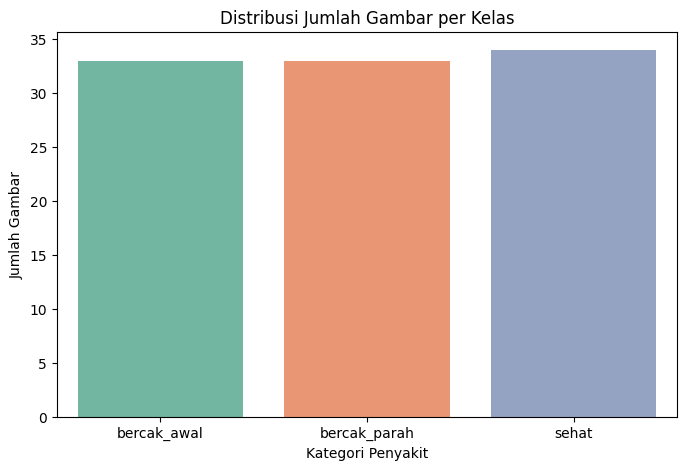

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Label', hue='Label', data=df_final, palette='Set2', legend=False)
plt.title('Distribusi Jumlah Gambar per Kelas')
plt.xlabel('Kategori Penyakit')
plt.ylabel('Jumlah Gambar')
plt.show()

## **9. Evaluasi Visual Scatter Plot Sebaran Data**

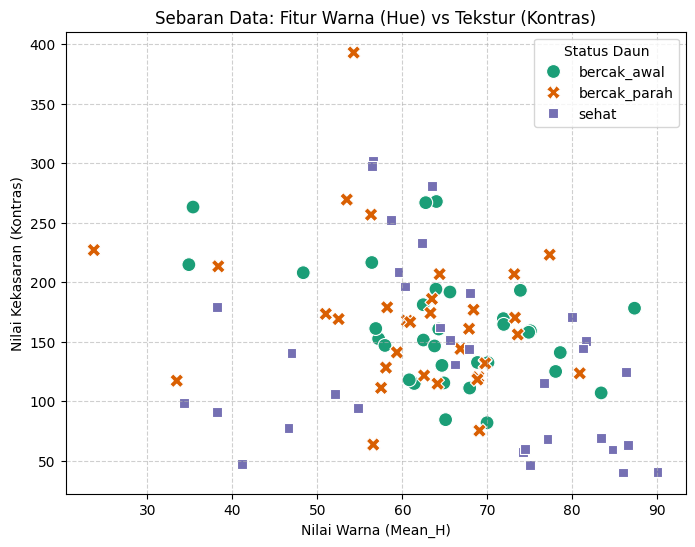

In [14]:
# Membandingkan 2 fitur utama untuk melihat bagaimana data berpisah
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Mean_H', y='Kontras', hue='Label', style='Label', data=df_final, s=100, palette='Dark2')
plt.title('Sebaran Data: Fitur Warna (Hue) vs Tekstur (Kontras)')
plt.xlabel('Nilai Warna (Mean_H)')
plt.ylabel('Nilai Kekasaran (Kontras)')
plt.legend(title='Status Daun')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **10. Evaluasi Visual Confusion Matrix**

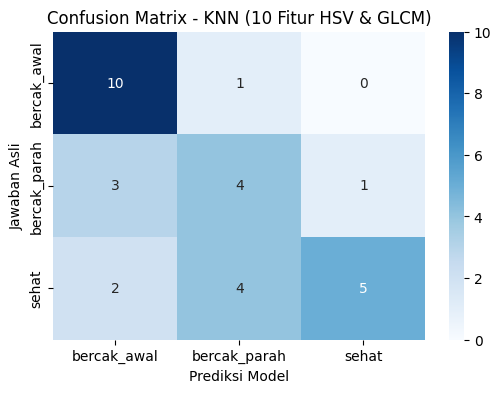

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix - KNN (10 Fitur HSV & GLCM)')
plt.xlabel('Prediksi Model')
plt.ylabel('Jawaban Asli')
plt.show()

# **Penerapan Perhitungan Matematis**


## **A. Ekstraksi Fitur (Mengubah Gambar ke Angka)**

### **1. Fitur Warna (Mean Hue)**
Komputer menjumlahkan semua nilai warna piksel pada ruang warna *Hue* dan mencari rata-ratanya.

**Rumus:**
$$MeanH = \frac{1}{n} \sum_{i=1}^{n} H_i$$

* **Contoh:** Jika kita memiliki 4 piksel sampel dengan nilai Hue: 60, 62, 58, 60.
* **Perhitungan:** $\frac{60+62+58+60}{4} = \mathbf{60}$.

### **2. Fitur Tekstur (Contrast GLCM)**
Menghitung tingkat kekasaran atau perbedaan intensitas antar piksel yang bertetangga menggunakan matriks GLCM.

**Rumus:**
$$Contrast = \sum_{i,j=0}^{N-1} P_{i,j} (i - j)^2$$

* **Logika Sederhana:**  Pada **Daun Sehat**, perbedaan antar piksel sangat kecil (mulus), sehingga nilai kontrasnya rendah.
    * Pada **Daun Sakit (Bercak)**, perbedaan intensitas piksel sangat tajam (kasar), sehingga nilai kontrasnya tinggi.

---


## **B. Normalisasi Z-Score (Penyetaraan Skala)**

Karena nilai fitur warna (puluhan) dan tekstur (ratusan/ribuan) memiliki rentang yang berbeda, kita harus menyetarakan skalanya menggunakan **StandardScaler** agar algoritma KNN dapat memberikan bobot yang adil pada setiap fitur.

**Rumus:**
$$Z = \frac{x - \mu}{\sigma}$$

* **Keterangan:** $x$ (nilai asli), $\mu$ (rata-rata), $\sigma$ (standar deviasi).
* **Contoh:** Misal nilai Kontras daun adalah **2500**, rata-rata dataset adalah **1500**, dan standar deviasi **500**.
* **Perhitungan:** $Z = \frac{2500 - 1500}{500} = \frac{1000}{500} = \mathbf{2.0}$.

---

## **C. Perhitungan Jarak Euclidean (Logika KNN)**

Untuk menentukan kategori daun baru, komputer menghitung jarak terdekat antara **Daun Baru** dengan **Data Latih** di dalam memori.

**Rumus Jarak (Euclidean Distance):**
$$d(A, B) = \sqrt{(H_1 - H_2)^2 + (C_1 - C_2)^2}$$

### Simulasi Perhitungan Manual:
Kita memiliki **Daun Baru** dengan nilai normalisasi: **Hue = 0.5** dan **Kontras = 1.2**. Kita bandingkan dengan data di memori komputer:

| Data Latih | Label | Nilai Hue (Z) | Nilai Kontras (Z) | Perhitungan Jarak Euclidean (d) |
| :--- | :--- | :--- | :--- | :--- |
| **Data A** | Sehat | 0.6 | 0.2 | $\sqrt{(0.5-0.6)^2 + (1.2-0.2)^2} = \mathbf{1.00}$ |
| **Data B** | Sakit | 0.4 | 1.1 | $\sqrt{(0.5-0.4)^2 + (1.2-1.1)^2} = \mathbf{0.14}$ |

**Kesimpulan:**
Karena jarak ke **Data B (0.14)** jauh lebih kecil dibandingkan ke Data A (1.00), maka algoritma **KNN** akan memprediksi bahwa Daun Baru tersebut berstatus **SAKIT**.